# Emotion Recognition

## Introduction

Facial Emotion Recognition is a fundamental problem in computer vision, aimed at enabling machines to interpret human affective states through visual cues. It plays a key role in applications such as **human computer** interaction, **mental health** analysis, **surveillance**, and **adaptive** user interfaces. The FER2013 dataset is a widely used dataset for this purpose, containing grayscale images of faces annotated with one of seven emotions: **Angry**, **Disgust**, **Fear**, **Happy**, **Sad**, **Surprise**, and **Neutral**.

In this project, we will preprocess this dataset, visualize it, build a Convolutional Neural Network (CNN) model, train the model, and evaluate its performance. The main goal is to achieve a reasonable accuracy in predicting the emotions while understanding the limitations and challenges of this task.

## Objectives

  1. Preprocess the FER2013 dataset, which includes image resizing, normalization, and label encoding.
  2. Visualize the dataset, including sample images and data distributions.
  3. Build a CNN model to classify emotions based on facial expressions.
  4. Train the model and monitor metrics such as accuracy and loss.
  5. Evaluate the model's performance using confusion matrices and classification reports.
  6. Understand the reasons behind the achieved accuracy and identify potential improvements.

## Techniques Used

*   **Convolutional Neural Networks (CNNs):** A powerful class of deep neural networks for processing visual data.
*   **Data Augmentation:** Applied to expand the training dataset and improve model generalization.
*   **Normalization:** Ensures that input data is scaled between 0 and 1 for faster convergence.
*   **Train-Test Split:** Helps evaluate the model's performance on unseen data.
*   **Visualization:** Provides insights into the dataset and model training process.

## Outputs and Expectation

By the end of this project, we will have:

*   A trained CNN model for emotion recognition.
*   Visualizations of training metrics, including accuracy and loss over epochs.
*   Performance evaluation metrics such as accuracy and confusion matrices.
*   A deeper understanding of the challenges in emotion recognition and possible avenues for improvement.





# 1. Import Libraries and Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import zipfile
import os
import warnings
warnings.filterwarnings('ignore')
# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
# tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.utils import to_categorical

# 2. Load and Explore Dataset

In [6]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# extract the zip file from the drive
zip_path = '/content/drive/MyDrive/FER.zip'
extract_path = '/content/FER'

if not os.path.exists(extract_path):
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [8]:
os.listdir('/content/FER')

['train', 'test']

In [9]:
# define directory paths for train and test
train_dir = os.path.join(extract_path, "train")
test_dir = os.path.join(extract_path, "test")

In [10]:
print("Train Data: ",os.listdir(train_dir))
print("Test Data: ",os.listdir(test_dir))

Train Data:  ['fear', 'surprise', 'disgust', 'happy', 'neutral', 'angry', 'sad']
Test Data:  ['fear', 'surprise', 'disgust', 'happy', 'neutral', 'angry', 'sad']


In [11]:
# mapping the emotions to numerical labels
emotion_mapping = {
    "fear": 0, "neutral": 1, "sad": 2, "angry": 3,
    "happy": 4, "disgust": 5, "surprise": 6
}

In [12]:
# Load images and labels
from PIL import Image
def load_images(directory):
  images = []
  labels = []
  for emotion in os.listdir(directory): # loop through each emotion directory
    emotion_dir = os.path.join(directory, emotion)
    if os.path.isdir(emotion_dir):
      for img_file in os.listdir(emotion_dir): # loop through each image directory
        img_path = os.path.join(emotion_dir, img_file)
        try:
          img = Image.open(img_path).convert("L") # coverts to grayscale
          img = img.resize((48,48)) # resize to 48 x 48
          images.append(np.array(img))
          labels.append(emotion_mapping[emotion])
        except Exception as e:
          print(f"Error loading image {img_path}: {e}")
  return np.array(images), np.array(labels)

Visual Representation of the 7 Emotions (Default)

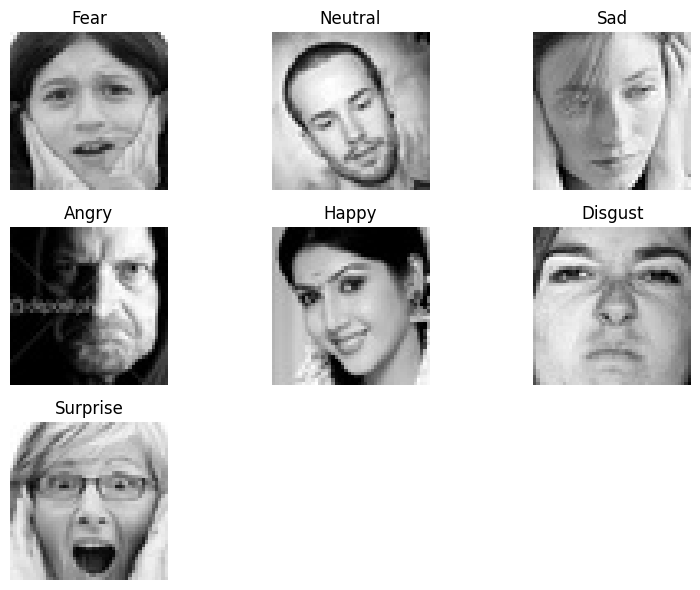

In [13]:
# visualize one image from each emotions
def visualize_image(directory):
  plt.figure(figsize =(8,6))
  for i, emotion in enumerate(emotion_mapping.keys()):
    emotion_dir = os.path.join(directory, emotion)
    image_path = os.path.join(emotion_dir, os.listdir(emotion_dir)[0])
    img = Image.open(image_path).convert("L")
    plt.subplot(3,3,i+1)
    plt.imshow(img, cmap="grey")
    plt.title(emotion.capitalize())
    plt.axis('off')
  plt.tight_layout()
  plt.show()
visualize_image(train_dir)

# 3. Data Preprocessing

Covert pixel values into grayscale 48x48 images and normalize  

In [14]:
# Load Train and Test Data
X_train, y_train = load_images(train_dir)
X_test, y_test = load_images(test_dir)

In [15]:
# Normalize pixel values
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [16]:
# Add a channel dimension
X_train = X_train.reshape(-1, 48, 48, 1)
X_test = X_test.reshape(-1, 48, 48, 1)

In [17]:
# Convert labels to one-hot encoding
y_train = to_categorical(y_train, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

# 4. Exploratory Data Analysis (EDA)

Visual class distributions and example images. Comparing the stats of the different emotions

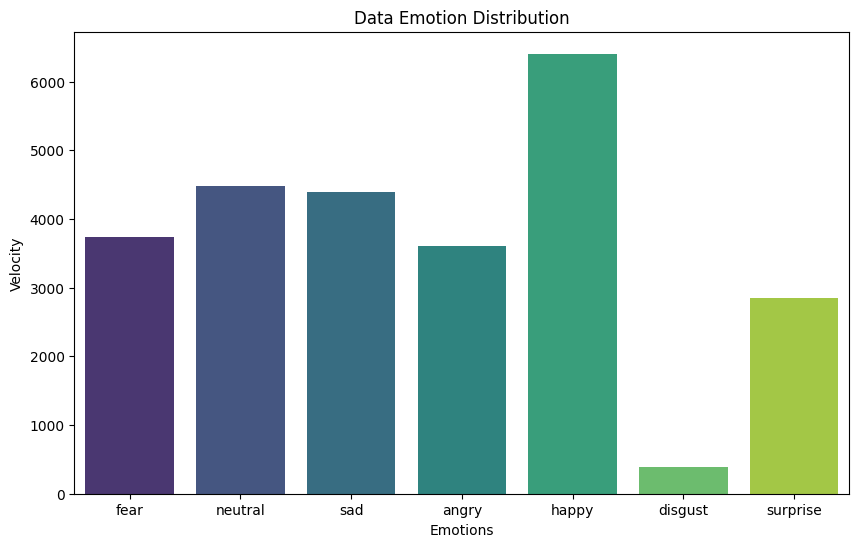

In [19]:
emotion_counts = np.argmax(y_train, axis=1)
plt.figure(figsize=(10, 6))
sns.countplot(x=emotion_counts, palette="viridis")
plt.title("Data Emotion Distribution")
plt.xlabel("Emotions")
plt.ylabel("Velocity")
plt.xticks(ticks=range(7), labels=list(emotion_mapping.keys()))
plt.show()

The visual Grid - Mean of the emotion ( shadow profiles ) and checking out the intensity difference

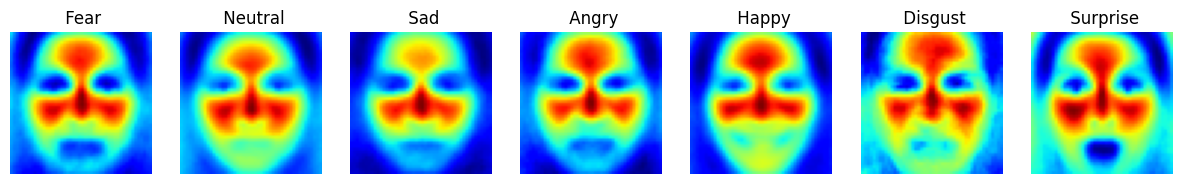

In [20]:
plt.figure(figsize=(15, 5))
for i, (emotion, label) in enumerate(emotion_mapping.items()):
    # Filter all images of this specific emotion
    indices = np.where(np.argmax(y_train, axis=1) == label)[0]
    # Calculate the average pixel value for this class
    mean_img = np.mean(X_train[indices], axis=0).reshape(48, 48)

    plt.subplot(1, 7, i+1)
    plt.imshow(mean_img, cmap='jet') # Using 'jet' highlights intensity differences
    plt.title(f" {emotion.capitalize()}")
    plt.axis('off')
plt.show()

# 5. Model Building (CNN)

The Hierarchial sequence of the CNN is,
*   Input -> Convolutional -> Activation Function -> Batch Normalization -> MaxPooling -> Flatten -> Dense -> Droupout -> Output(Dense)

In [21]:
def build_cnn_model(input_shape=(48, 48, 1)):
    model = Sequential([

        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape), #block1
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), activation='relu'), #bloack2
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(128, (3, 3), activation='relu'), #block3
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.4),
        # Flatten and Dense layers
        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        # Output layer for 7 emotions
        Dense(7, activation='softmax')
    ])
    return model

In [22]:
#compile the model
cnn_model = build_cnn_model()
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])


In [23]:
# Train the model
history = cnn_model.fit(X_train, y_train, epochs=30, batch_size=64, validation_data=(X_val, y_val), verbose=1)

Epoch 1/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 139s 335ms/step - accuracy: 0.2836 - loss: 2.0753 - val_accuracy: 0.3197 - val_loss: 1.6821
Epoch 2/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 135s 333ms/step - accuracy: 0.4025 - loss: 1.5675 - val_accuracy: 0.4789 - val_loss: 1.3734
Epoch 3/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 135s 334ms/step - accuracy: 0.4535 - loss: 1.4242 - val_accuracy: 0.4922 - val_loss: 1.3586
Epoch 4/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 141s 331ms/step - accuracy: 0.4782 - loss: 1.3595 - val_accuracy: 0.4890 - val_loss: 1.3262
Epoch 5/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 132s 326ms/step - accuracy: 0.4968 - loss: 1.3140 - val_accuracy: 0.4974 - val_loss: 1.2977
Epoch 6/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 134s 330ms/step - accuracy: 0.5167 - loss: 1.2689 - val_accuracy: 0.5416 - val_loss: 1.2251
Epoch 7/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 133s 330ms/step - accuracy: 0.5247 - loss: 1.2434 - val_accuracy: 0.5326 - val_loss: 1.2403
Epoch 8/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 130s 321ms/step - accuracy: 0.5357 -

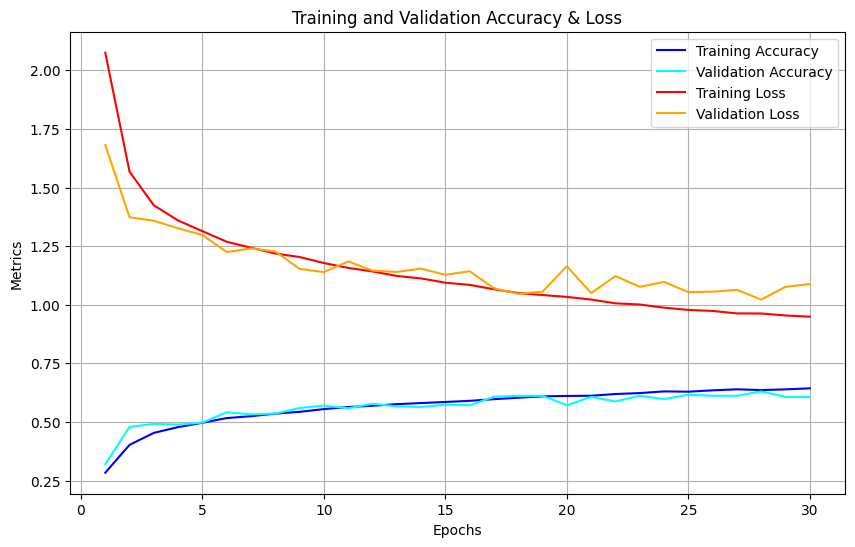

In [24]:
# Plot accuracy and loss
def plot_training_history(history):
    epochs = range(1, len(history.history['accuracy']) + 1)

    plt.figure(figsize=(10, 6))
    # Plot training and validation accuracy
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', color='blue')
    plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy', color='cyan')

    # Plot training and validation loss
    plt.plot(epochs, history.history['loss'], label='Training Loss', color='red')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss', color='orange')

    plt.title('Training and Validation Accuracy & Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Metrics')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_training_history(history)

# 6. Evaluate the Model

In [25]:
# Evaluate Model
test_loss, test_accuracy = cnn_model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.5862 - loss: 1.1027
Test Loss: 1.1027, Test Accuracy: 0.5862


In [26]:
# Confusion Matrix
y_pred = np.argmax(cnn_model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
conf_matrix = confusion_matrix(y_true, y_pred)

225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step


# 7. Visualize the Result

90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step


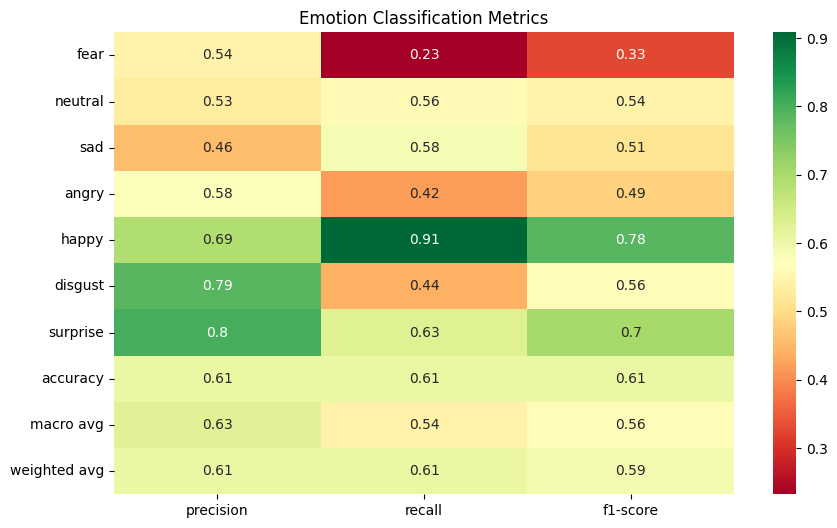

In [27]:
# 1. Get predictions
y_pred = cnn_model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

# 2. Create report
report = classification_report(y_true, y_pred_classes,target_names=list(emotion_mapping.keys()),output_dict=True)
# 3. Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap='RdYlGn')
plt.title('Emotion Classification Metrics')
plt.show()

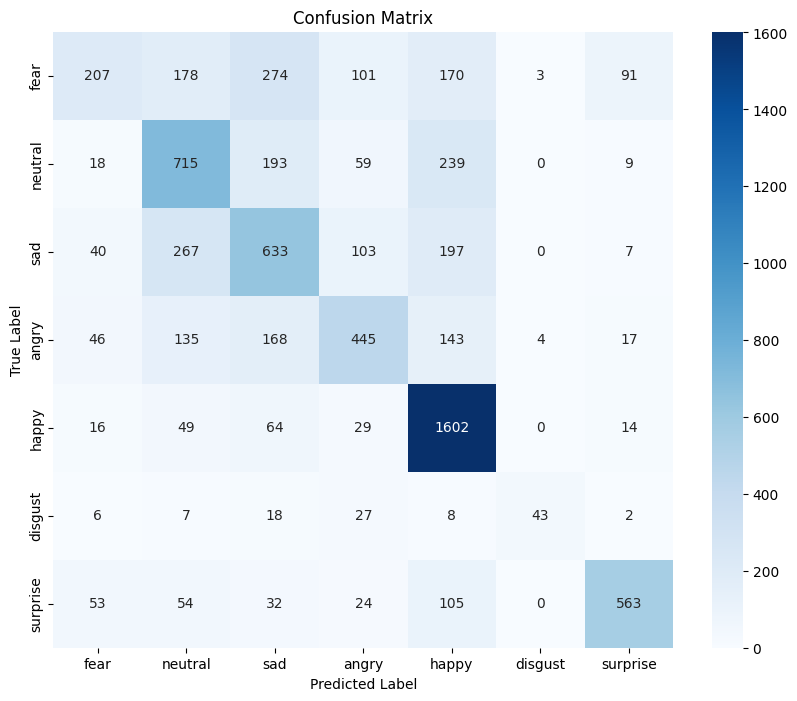

In [28]:
# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=list(emotion_mapping.keys()), yticklabels=list(emotion_mapping.keys()))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Conclusion

In this project, we successfully built an CNN based model to classify emotions using the FER2013 dataset. While the accuracy achieved was modest, it highlights the inherent challenges in emotion recognition due to factors such as:

*  **Dataset Quality:**  The FER2013 dataset contains grayscale images that are sometimes low in resolution, making it difficult to extract meaningful features.
*   **Class Imbalance:** Certain emotions like "Disgust" have very few samples, which negatively impacts the model's ability to generalize.
*   **Ambiguity of Emotions:** Some emotions have overlapping facial features, which increases the complexity of classification.

The choice of a CNN model was motivated by its proven effectiveness in image processing tasks. The convolutional layers help extract spatial hierarchies in images, making them well-suited for recognizing patterns in facial expressions.

## Future Work

To improve accuracy, we can explore the following:

*  Use Transfer Learning with pre-trained models like ResNet or EfficientNet.
*  Apply advanced data augmentation techniques.
*  Address class imbalance using methods like oversampling or synthetic data generation (e.g., SMOTE for image data).
*   Increase dataset diversity by incorporating additional emotion datasets.

Emotion recognition remains a challenging yet exciting field with applications in healthcare, human-computer interaction, and psychology. Our results provide a foundation for further exploration in this domain.
